# 42 - Accuracy, Recall, Precision, F1

**Section:** Model Evaluation | **Prereqs:** `More on Data/CodeChallenge_UnbalancedData.ipynb` | **Next:** `Model Evaluation/ARPF_WineDataset.ipynb`

Every binary prediction lands in one of four boxes:

|  | Predicted positive | Predicted negative |
|---|---|---|
| **Actually positive** | TP | FN (miss) |
| **Actually negative** | FP (false alarm) | TN |

Every metric is a different ratio of those four numbers:

- **Accuracy** = (TP+TN)/all - what fraction did I get right? Useless when the
  classes are imbalanced.
- **Precision** = TP/(TP+FP) - when I say positive, how often am I right?
  *Cost of a false alarm.*
- **Recall** = TP/(TP+FN) - of the real positives, how many did I catch?
  *Cost of a miss.*
- **F1** = harmonic mean of precision and recall - one number when both matter.

**Precision and recall trade off against each other**, and the exchange rate is
your decision threshold. Predict positive more often and recall rises while
precision falls. Which you want is a domain question, not a modelling one: a
cancer screen wants recall (a miss is fatal, a false alarm costs a second test);
a spam filter wants precision (a lost real email is worse than a spam that got
through).

**This notebook's method:** simulate 1000 random confusion matrices and plot the
metrics against each other, so you can see that the same accuracy is consistent
with a wide range of F1 - which is the argument for never reporting accuracy
alone.

In [73]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, roc_curve

In [39]:
# 1000 simulated confusion matrices. TP and TN are drawn at random; FN and FP
# are whatever is left, so each simulated model has N positives and N negatives.
# The metrics are computed straight from the definitions - no model, no data,
# just the arithmetic.
# Note F1 = TP/(TP + (FP+FN)/2) is the harmonic mean of precision and recall,
# written in its shortest form.
N = 100

noExperiments = 1000

precision = torch.zeros(noExperiments)
F1 = torch.zeros(noExperiments)
recall = torch.zeros(noExperiments)
acc = torch.zeros(noExperiments)


for i in range(noExperiments):

  TP = np.random.randint(1,N)
  FN = N - TP
  TN = np.random.randint(1,N)
  FP = N - TN


  acc[i] = (TP+TN)/(2*N)
  precision[i] = TP / (TP + FP)
  recall[i] = TP / (TP+FN)
  F1[i] = TP / (TP + (FP+FN)/2)


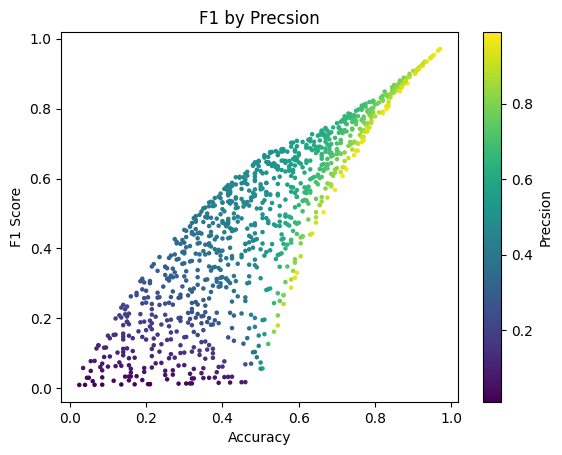

In [48]:
# Accuracy vs F1, coloured by precision. The spread is the point: at any given
# accuracy, F1 ranges widely. Two models with identical accuracy can be very
# different models.
plt.scatter(acc,F1,s=5, c=precision)
plt.colorbar(label="Precsion")
plt.ylabel('F1 Score')
plt.xlabel("Accuracy")
plt.title("F1 by Precsion");

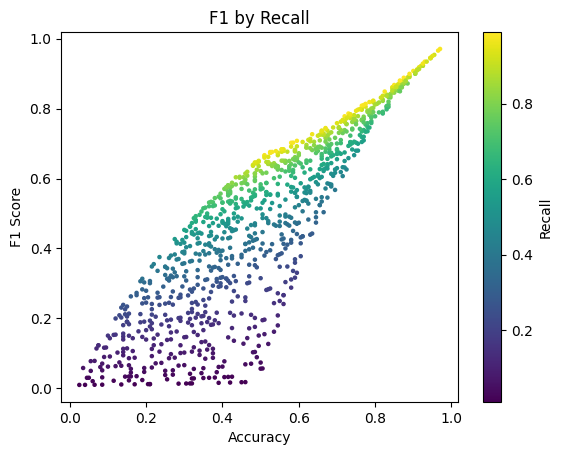

In [43]:
# The same scatter coloured by recall. Colour now varies along the other
# diagonal - because precision and recall pull F1 in opposite directions.
# Read the two plots together: high F1 requires BOTH to be high, while high
# accuracy requires neither.
plt.scatter(acc,F1,s=5, c=recall)
plt.colorbar(label="Recall")
plt.ylabel('F1 Score')
plt.xlabel("Accuracy")
plt.title("F1 by Recall");

## Conclusion

The scatter plots illustrate the relationships between Accuracy, F1 Score, Precision, and Recall. The first plot shows that as Accuracy increases, F1 Score generally increases, with higher Precision values tending towards the upper right corner of the plot. The second plot similarly shows that as Accuracy increases, F1 Score also tends to increase, and higher Recall values are concentrated in the upper right. Overall, the plots demonstrate the interplay of these metrics, where high Accuracy and F1 Scores are typically achieved when both Precision and Recall are also high. However, it's important to note that high accuracy alone does not guarantee high F1, especially when there is an imbalance between Precision and Recall, as shown by the spread of points for lower Accuracy values.

## Definitions in simplest words

*   **Recall:** Out of all the actual positive cases, how many did we correctly identify? (Think of it as catching all the "good guys".)
*   **Precision:** Out of all the cases we predicted as positive, how many were actually positive? (Think of it as not crying "wolf" too often.)
*   **F1 Score:** A single score that balances both Recall and Precision. It's useful when you need to consider both equally.